In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
#color_list = sns.color_palette() + sns.color_palette("Set2") + sns.color_palette("Set3")
color_list = (
    sns.color_palette("colorblind", 10) +
    sns.color_palette("Dark2", 8) +
    sns.color_palette("tab20", 20)
)

dim = 3
save_dir = f'data/{dim}d/rpa'

# single run with and without refinent (maybe also compare with tprc method)
# rest with more runs

Starting serial run at: 2026-06-03 20:14:22.123716


In [ ]:
from scripts.scba import *

lat = LATTICE(dim=2)
nk = 200
lat.get_bz(nk, ibz=True)
lat.get_e_k()

niw = 64
beta = 1/0.4
n = 1.
scba = SCBA(lat, niw, nk)
scba.run(0.1, beta, n, ibz=True)

S_iwk = lat.unfold_f_iwk(scba.S_iwk)

S_grid = S_iwk.reshape((niw,nk,nk))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

c0 = axes[0].contourf(S_grid[0].real, levels=50, cmap='RdBu_r')
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r'Re $\Sigma(i\omega_0, \mathbf{k})$')

c1 = axes[1].contourf(S_grid[0].imag, levels=50, cmap='RdBu_r')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r'Im $\Sigma(i\omega_0, \mathbf{k})$')

plt.tight_layout()
plt.show()

In [ ]:
# G(iω_n, k) = 1 / (iω_n - ε_k - Σ(iω_n, k))
# At n=0 (first positive Matsubara freq): ω_0 = π/β

omega_0 = np.pi / beta  # = π · T

# ε_k on full BZ, shape (nk, nk)
e_k_full = lat.unfold_f_k(lat.e_k)   # adjust to your API

# Σ(iω_0, k) — already computed above
# S_k_n0 shape (nk, nk), complex

G_k_n0 = 1.0 / (1j * omega_0 - e_k_full - S_iwk[0].imag)

# Proxy spectral weight: -Im G(iω_0, k) / π
A_proxy = -G_k_n0.imag / np.pi

plt.figure(figsize=(5, 4))
plt.contourf(A_proxy.reshape(nk,nk), levels=50, cmap='inferno')
plt.colorbar(label=r'$-\mathrm{Im}\, G(i\omega_0,\mathbf{k})\,/\,\pi$')
plt.title(r'Proxy spectral weight at $i\omega_0$')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

square = LATTICE(dim=2, tp=0.)
nk = 200

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

# --- Compute A(k,0) ---
eta = 0.01  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=0.9, beta=1/1)
Ak0 = (1/np.pi) * eta / (eta**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [-0.2, 0., 0.2]

nk = 200

k_mesh, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.01
n_list = [0.8, 0.9, 1.]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tp in zip(axes, tp_list):
    square = LATTICE(dim=2, tp=tp)
    
    square.get_e_k(nk)
    eps = square.e_k.data[:, 0, 0].real
    eps = eps.reshape(nk, nk)
    eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

    cf = ax.contourf(kx, ky, eps, levels=50)

    mu_list = [get_mu(e_k=square.e_k, n_goal=n, beta=1/T) for n in n_list]
    print(tp, mu_list)
    ax.contour(kx, ky, eps, levels=mu_list[:-1], colors='black', linewidths=2)
    ax.contour(kx, ky, eps, levels=[mu_list[-1]], colors='red', linewidths=2)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(f"t'/t = {tp}")
    ax.set_aspect('equal')

fig.colorbar(cf, ax=axes, label=r'$\varepsilon(k)$')
plt.show()

In [ ]:
n = 0.8
T_list = np.linspace(0.01, 0.1, 10)
U = 3

nk = 100
lat = LATTICE(tp=0.05)
lat.get_bz(nk, ibz=True)
lat.get_e_k()

refine_ratio = 2
nk_fine = int(nk*refine_ratio)
lat.get_bz(nk_fine, ibz=True, fine=True)
lat.get_e_k(fine=True)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel('$Q_z$')

q_path = ([1,1,0],[1,1,1])
qz_grid = get_grid_from_path(q_path, lat.k_vecs)[:,-1]
step = qz_grid[1] - qz_grid[0]
Qz = []
Qz_ref = []
for i, T in enumerate(T_list):
    mu = get_mu(lat.e_k_fine, n, 1/T, ibz_w_k=lat.ibz_w_k_fine)

    Q, _, invchi0_grid = get_invchi0_min(lat, mu, 1/T, nk, q_path, 'lindhard')
    Q_ref, invchi0_Q = refine_min(lat, mu, 1/T, nk, Q, q_path, refine_ratio=refine_ratio)
    fit_out, grid_pts = fit_invxi(lat, mu, 1/T, U, nk_fine, Q_ref)
    
    Qz.append(Q[-1])
    Qz_ref.append(Q_ref[-1])
    if i%2 == 0:
        ax[0].plot(qz_grid, invchi0_grid-U, 'o', markersize=4, label=f'T={T:.2f}')

        par, _ = fit_out
        color = ax[0].lines[-1].get_color()
        q_grid_fitted, invchi_grid_fitted = grid_pts
        OZ_curve = [1/OZ(np.pi*(qz - Q_ref[-1]), *par) for qz in q_grid_fitted[:,-1]]
        ax[0].plot(q_grid_fitted[:,-1], invchi_grid_fitted, color=color)
        ax[0].plot(q_grid_fitted[:,-1], OZ_curve, '--', color='black', linewidth=0.7)
        ax[0].plot(Q_ref[-1], invchi0_Q-U, 'x', markersize=4, color='black')
    
    print(i)

ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[1].plot(T_list, Qz_ref, '--', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

In [ ]:
U = 3
n = 0.75
T_list = np.linspace(0.001, 0.01, 10)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard, RPA (U={U}, n={n})'

nk_list = list(range(90, 101, 2))
refine_ratio = 3
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'lindhard', 'q_path': ([1,1,0],[1,1,1]),
               'refine_ratio': refine_ratio, 'get_xi': True} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['invxi'] = sum([results['invxi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1),
                        title=title, label=f'$n_k={nk}*{refine_ratio}$', figure=fig, alpha=0.8)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), fit=False, x_exp=(0.5,1),
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

U: 3.000, n: 0.740: Completed 15 jobs in 17.4 seconds
U: 3.000, n: 0.745: Completed 15 jobs in 16.6 seconds
U: 3.000, n: 0.750: Completed 15 jobs in 15.4 seconds
U: 3.000, n: 0.755: Completed 15 jobs in 16.9 seconds
U: 3.000, n: 0.760: Completed 15 jobs in 17.5 seconds


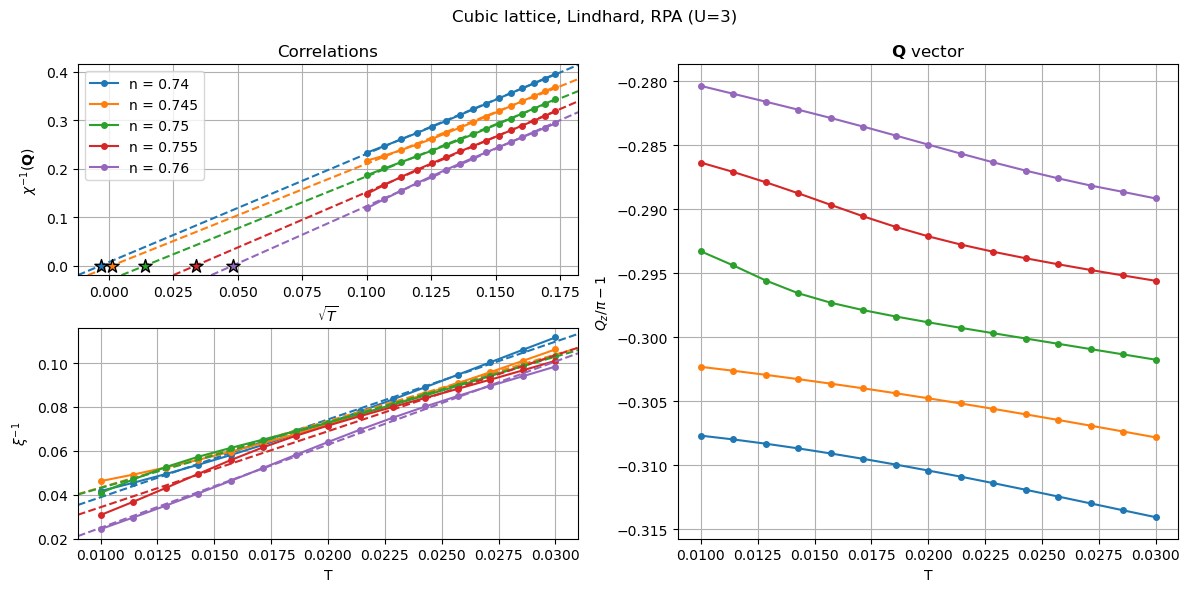

In [4]:
U = 3
n_list = np.linspace(0.74, 0.76, 5)
T_list = np.linspace(0.01, 0.03, 15)
title = f'Cubic lattice, Lindhard, RPA (U={U})'

lat = LATTICE()
initialize_bz(lat, nk=50, refine=True, ibz=True, refine_ratio=2)

results_list = []
for n in n_list:
    par_list = [{'U': U, 'n': n, 'T': T} for T in T_list]
    results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0], [1,1,1]), method='lindhard', get_xi=True, fit=True, verbose=True, workers=6))

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    #Tc_xi = results['fitxi']['Xc']
    #nu = results['fitxi']['b']
    #print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1), fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.75, 0.77, 5)
T_list = np.linspace(0.05, 0.15, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 50
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'tp': 0.1,
               'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 2, 'get_xi': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(1,1), fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    #_, axs = fig
    #color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    #axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

In [ ]:
fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1), fit=True,
                        title=title, label=f'n = {n}', figure=fig)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.87, 0.89, 5)
T_list = np.concatenate([np.linspace(0.005, 0.02, 15), np.linspace(0.02, 0.20, 20)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 100
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'tp': 0.2,
               'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 3, 'get_xi': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc_chi = results['fitchi']['Xc']
    gamma = results['fitchi']['b']
    Tc_xi = results['fitxi']['Xc']
    nu = results['fitxi']['b']
    print(f"n = {n} :\n chi: gamma = {gamma:.3f}, Tc = {Tc_chi:.3f}, xi: nu = {nu:.3f}, Tc = {Tc_xi:.3f}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=(0.5,1), fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[0][1]/fit[0][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].scatter(-fit[1][1]/fit[1][0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    #axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 10)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. TPRF, RPA (U={U})'

nk = 30
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_fft', 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_fft = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_tprf', 'niw': niw} for par_dict in par_list]
results_list_tprf = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_fft, res_tprf in zip(results_list_fft, results_list_tprf):
    n = res_fft['par_list'][0]['n']
    fig, fit = pcut_chi(res_fft, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_tprf, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U})'

nk = 50
niw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'niw': niw, 'niw_extr': True} for par_dict in par_list]
results_list_mats = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
results_list_lindh = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_mats, res_lindh in zip(results_list_mats, results_list_lindh):
    n = res_mats['par_list'][0]['n']
    print(f"n = {n} : exp_mats = {res_mats['gamma']}, exp_lindh = {res_lindh['gamma']}")
    fig, fit = pcut_chi(res_mats, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_lindh, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

In [ ]:
U = 3
n = 0.85
T_list = np.linspace(0.01, 0.05, 15)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U}, n={n})'

nk = 20
niw_list = 1024//np.array([4,3,2,1])

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'niw': niw, 'niw_extr': False, 'tp': 0.2, 'refine': False} for niw in niw_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for results in results_list:
    niw = results['niw']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=False, x_exp=0.5, title=title, label=f'$n_{{i\omega}}={niw}$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, niw=niw_list[-1], niw_extr=True, tp=0.2, refine=False)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label=r'$n_{{i\omega}}\to\infty$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, method='lindhard', q_path=([1,1,0], [1,1,1]), tp=0.2, refine=False)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label='Lindhard', figure=fig)

plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 15)

nk = 82
file = f'{save_dir}/nTdiag_U3'
if os.path.exists(file):
    results = HDFread_list(file, ['Xc'])
    n_old = [par_list[0]['n'] for par_list in results['par_list']]
    Tc_old = [x[0] for x in results['Xc']]
    Tc = np.interp(n_list, n_old, Tc_old)
else:
    print(f'file {file} does not exist!')

par_list = []
for i, n in enumerate(n_list):
    par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'lindhard', 'q_path': ([1,1,0], [1,1,1]),
               'fit': True, 'fit_type': [critical1, critical2], 'refine_ratio': 2} for par_dict in par_list]
results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.7, 1)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_z/\pi-1$')

results = HDFread_list(f'{save_dir}/nTdiag_U3', ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
n_fits = len(results['Xc'][0])

for i in range(n_fits):
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[i][-1]-1 for Q in results['Qc']]
    Xc = [x[i] for x in results['Xc']]
    Xc_err = [x[i] for x in results['Xc_err']]
    gamma = [x[i] for x in results['gamma']]
    gamma_err = [x[i] for x in results['gamma_err']]
    mu_c = [x[i] for x in results['mu_c']]
    print(mu_c)

    ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, gamma, gamma_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., Xc, n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 24)
T_list = np.linspace(0., 0.05, 15)

nk = 80
niw = 256
tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.73, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]
    print(len(n_list), n_list)
    n_list.pop(-4)
    print(len(n_list), n_list)
    results['Xc'].pop(-4)
    results['Xc_err'].pop(-4)
    results['gamma'].pop(-4)
    results['gamma_err'].pop(-4)
    results['mu_c'].pop(-4)

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        Qj[j].pop(-4)
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(0., results['mu_c'], n_list)
    #print(n_crit2, tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.87, 0.91, 18)
T_list = np.linspace(0., 0.2, 20)

nk = 80
niw = 256
tp_list = [0.15, 0.2, 0.25]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': True, 'refine_ratio': 2} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1]), 'refine_ratio': 2} for par_dict in par_list]
    sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.87, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.3)
#ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0.15, 0.2, 0.25]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(0., results['mu_c'], n_list)
    print(n_crit2, tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 50
niw = 128
tp_list = [-0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'niw': niw, 'niw_extr': True, 'refine': False} for #par_dict in par_list]
    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 
                   'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., -0.05, -0.1, -0.15, -0.2]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc', 'mu_c'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qj = [[Q[j]-1 for Q in results['Qc']] for j in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for j, a in enumerate(ax[2:]):
        a.plot(n_list, Qj[j], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    n_crit2 = np.interp(-tp, results['mu_c'], n_list)
    print(tp, results['mu_c'])
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.axvline(n_crit2, linestyle='-.', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/negtp.png', dpi=100)
plt.show()

In [ ]:
save_dir = f'data/{dim}d/rpa_ba'

In [ ]:
U = 3
n_list = np.linspace(0.73, 0.91, 12)
T_list = np.linspace(0., 0.04, 15)

nk = 100
niw = 128
Gamma_list = [0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma, 'niw': niw, 'niw_extr': True, 'refine': False} for par_dict in par_list]
    #sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'S_iwk_list': -1.j*Gamma,
    #               'method': 'lindhard', 'refine': True, 'q_path': ([1,1,0], [1,1,1])} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    #Tc = np.array([res['Xc'] for res in results])
    #i_crit = np.argwhere(Tc > 0)[0,0]
    #n_list = n_list[max(i_crit-2,0):]

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.set_xlim(0.72, 0.9)
    a.invert_xaxis()

ax[0].set_ylim(0., 0.2)
ax[1].set_ylim(0., 1.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

Gamma_list = [0., 0.01, 0.025, 0.05, 0.1]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=rf"$\Gamma={Gamma}$", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [ ]:
import tracemalloc

tracemalloc.start()
lattice = LATTICE()
nk = 300
lattice.get_k_mesh(nk, ibz=True)
lattice.get_e_k()
print(len(lattice.e_k),'/',nk**3, lattice.e_k)
print(lattice.ibz_w_k.sum())

current, peak = tracemalloc.get_traced_memory()
print(f"peak during fourier: {peak / 1e6:.1f} MB")
tracemalloc.stop()